--- QBCA FINAL PERFORMANCE REPORT ---
                    Metric Your Implementation Paper Benchmark (G5)
   Initialization Time (s)             0.00131              0.00396
    Average Distortion (φ)            0.004225             0.007487
Avg. Distance Computations                0.37                ~1.50
        Total CPU Time (s)              0.0115              ~0.0400


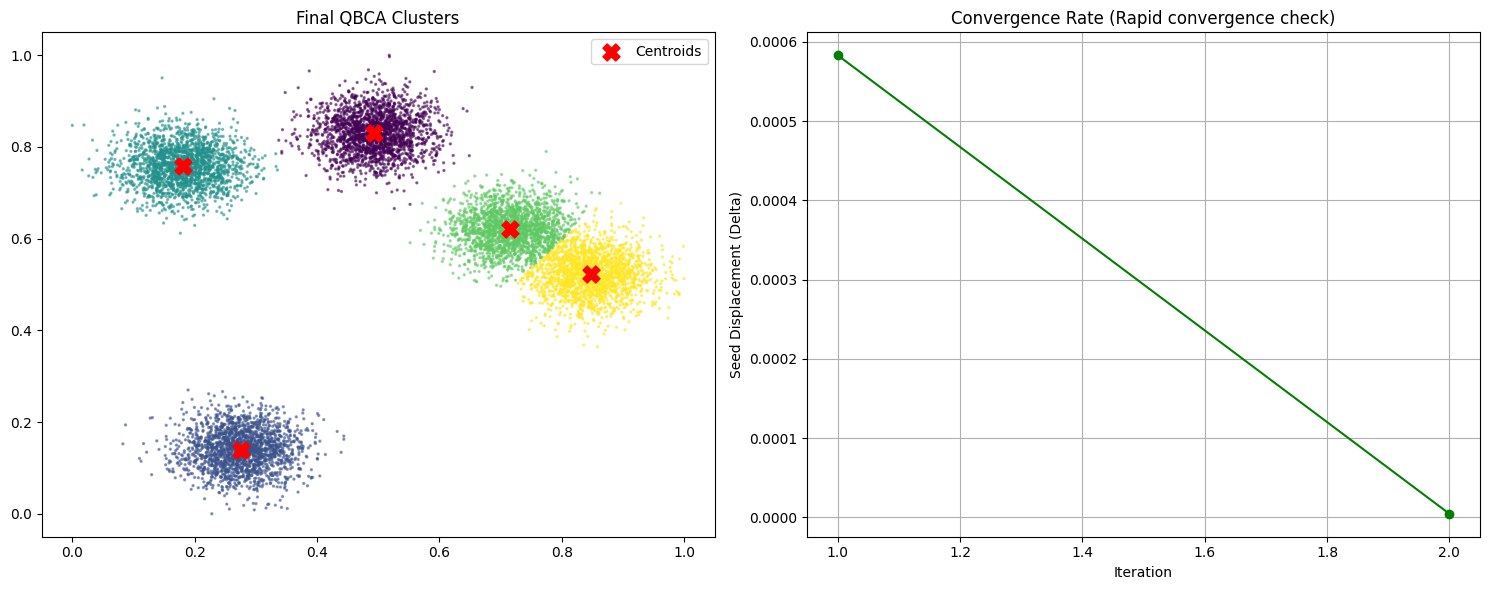

<Figure size 640x480 with 0 Axes>

In [1]:
"""QBCA analysis notebook."""

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from qbca import QBCA
import time
import pandas as pd

# 1. Setup: Generate synthetic data to match "Gaussian (5)"
n_samples = 10000
X_raw, _ = make_blobs(n_samples=n_samples, centers=5, n_features=2, random_state=42)

# CRITICAL FIX: Scale the data to [0, 1] so the spatial distortion
# matches the mathematical scale of the paper's G5 dataset.
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

# 2. Execution
# Note: Because the data space is now [0,1], the shifts are smaller.
# A threshold of 1e-5 is more appropriate to ensure full convergence.
model = QBCA(k=5, threshold=0.00001, max_iter=30)
start_total = time.time()
labels, centers, history = model.fit(X)
end_total = time.time()

# 3. Metric Calculation [cite: 563, 566]
avg_distortion, avg_dist_comp = model.get_metrics(X, labels)
total_cpu_time = end_total - start_total

# 4. Comparative Report Generation
report_data = {
    "Metric": [
        "Initialization Time (s)",
        "Average Distortion (φ)",
        "Avg. Distance Computations",
        "Total CPU Time (s)"
    ],
    "Your Implementation": [
        f"{model.init_time:.5f}",
        f"{avg_distortion:.6f}",
        f"{avg_dist_comp:.2f}",
        f"{total_cpu_time:.4f}"
    ],
    "Paper Benchmark (G5)": [
        "0.00396",
        "0.007487",
        "~1.50",
        "~0.0400"
    ]
}

df_report = pd.DataFrame(report_data)
print("--- QBCA FINAL PERFORMANCE REPORT ---")
print(df_report.to_string(index=False))

# 5. Visualization [cite: 284, 351]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Cluster Plot
ax1.scatter(X[:, 0], X[:, 1], c=labels, s=2, cmap='viridis', alpha=0.5)
ax1.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150, label='Centroids')
ax1.set_title("Final QBCA Clusters")
ax1.legend()

# Convergence Plot [cite: 394]
shifts = [h['shift'] for h in history]
ax2.plot(range(1, len(shifts) + 1), shifts, marker='o', color='green')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Seed Displacement (Delta)")
ax2.set_title("Convergence Rate (Rapid convergence check)")
ax2.grid(True)

plt.tight_layout()

plt.show()
plt.tight_layout()
plt.show()